# machine.ipynb

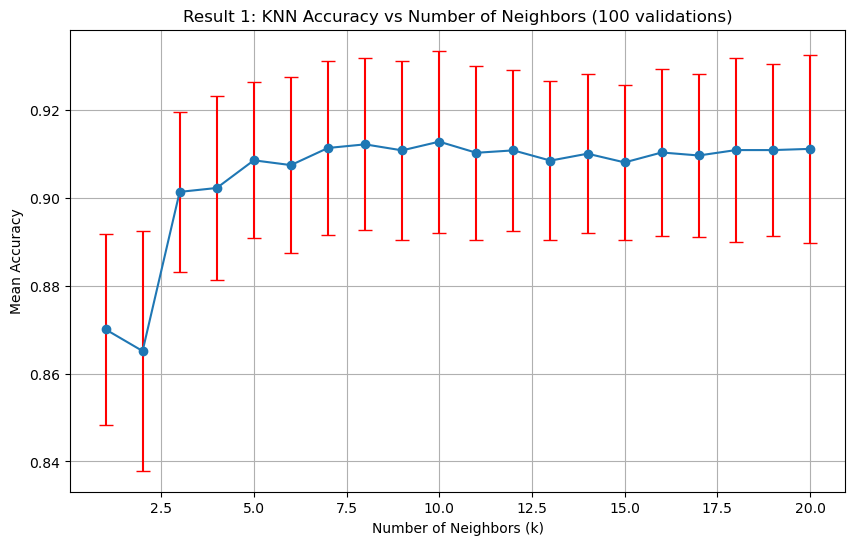

Best K based on mean accuracy: 10


C:\Users\youza\AppData\Local\Temp\ipykernel_51140\3006700489.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([scores_high, scores_low], labels=['High Spenders', 'Low Spenders'])


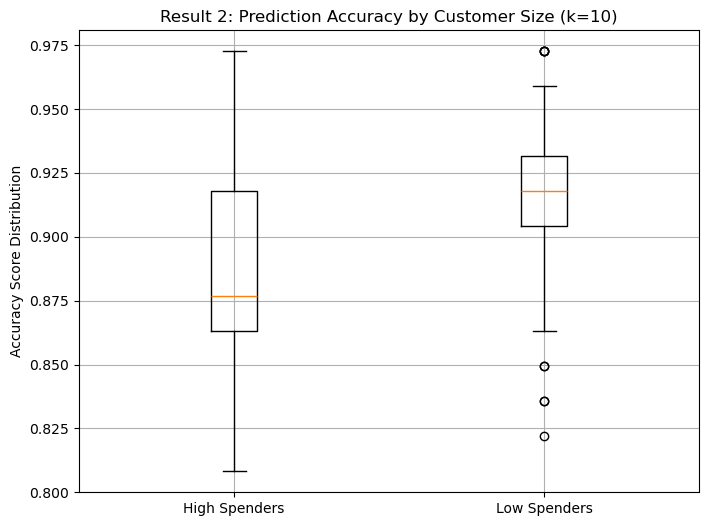

Mean Accuracy High Spenders: 0.888
Mean Accuracy Low Spenders: 0.915


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('Wholesale customers data.csv')

y = df['Channel']
X = df.drop(['Channel', 'Region'], axis=1) 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = range(1, 21)
mean_accuracies = []
std_accuracies = []

for k in k_values:
    temp_scores = []
    for i in range(100):
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33, random_state=i)
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        pred = knn.predict(X_test)
        temp_scores.append(accuracy_score(y_test, pred))
    
    mean_accuracies.append(np.mean(temp_scores))
    std_accuracies.append(np.std(temp_scores))

plt.figure(figsize=(10, 6))
plt.errorbar(k_values, mean_accuracies, yerr=std_accuracies, fmt='-o', capsize=5, ecolor='red')
plt.title('Result 1: KNN Accuracy vs Number of Neighbors (100 validations)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy')
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(mean_accuracies)]
print(f"Best K based on mean accuracy: {best_k}")

df['Total_Spend'] = df[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].sum(axis=1)
median_spend = df['Total_Spend'].median()

high_spenders = df[df['Total_Spend'] > median_spend].copy()
low_spenders = df[df['Total_Spend'] <= median_spend].copy()

def evaluate_subset(subset_df, name):
    y_sub = subset_df['Channel']
    X_sub = subset_df.drop(['Channel', 'Region', 'Total_Spend'], axis=1)
    X_sub_scaled = scaler.fit_transform(X_sub)
    
    scores = []
    for i in range(100):
        X_tr, X_te, y_tr, y_te = train_test_split(X_sub_scaled, y_sub, test_size=0.33, random_state=i)
        knn = KNeighborsClassifier(n_neighbors=best_k) # Use the best K found above
        knn.fit(X_tr, y_tr)
        scores.append(accuracy_score(y_te, knn.predict(X_te)))
    return scores

scores_high = evaluate_subset(high_spenders, "High Spenders")
scores_low = evaluate_subset(low_spenders, "Low Spenders")

plt.figure(figsize=(8, 6))
plt.boxplot([scores_high, scores_low], labels=['High Spenders', 'Low Spenders'])
plt.title(f'Result 2: Prediction Accuracy by Customer Size (k={best_k})')
plt.ylabel('Accuracy Score Distribution')
plt.grid(True)
plt.show()

print(f"Mean Accuracy High Spenders: {np.mean(scores_high):.3f}")
print(f"Mean Accuracy Low Spenders: {np.mean(scores_low):.3f}")